# 03 - Naive Baseline: Seasonal Climatology

Single naive model (seasonal climatology) with train/val/test evaluation.

In [ ]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from src.data.preprocessing import load_processed_data
from src.data.splitting import time_series_split
from src.models.naive import (
    fit_climatological_mean_by_season,
    predict_climatological_mean_by_season,
)
from src.models.pipeline import run_pipeline, evaluate_on_test
from src.evaluation.metrics import mae, rmse

P_NOM = 13_500.0
TARGET = 'Solarproduktion'
RESULTS_DIR = Path('../../results/00_naive_baseline')
RUN_TEST = False  # flip to True once, deliberately, when finalizing results

In [ ]:
df = load_processed_data()
train, val, test = time_series_split(df)

for name, split_df in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: {split_df['timestamp'].min().date()} -> {split_df['timestamp'].max().date()} ({len(split_df):,})")

In [100]:
seasonal_means = fit_climatological_mean_by_season(train, TARGET)

y_train = train.set_index('timestamp')[TARGET]
y_val = val.set_index('timestamp')[TARGET]
y_test = test.set_index('timestamp')[TARGET]

pred_train = predict_climatological_mean_by_season(seasonal_means, train).set_axis(y_train.index)
pred_val = predict_climatological_mean_by_season(seasonal_means, val).set_axis(y_val.index)
pred_test = predict_climatological_mean_by_season(seasonal_means, test).set_axis(y_test.index)


In [101]:
pers_train = persistence_forecast(y_train)
pers_val = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)


## Beispielwochen je Jahreszeit

Für jede Jahreszeit wird eine Beispielwoche gezeigt (Ist vs. saisonale Klimatologie). Primär aus dem **Test-Split**; falls eine Jahreszeit dort fehlt (z. B. Herbst), wird sie aus dem **Validation-Split** ergänzt und im Titel gekennzeichnet.

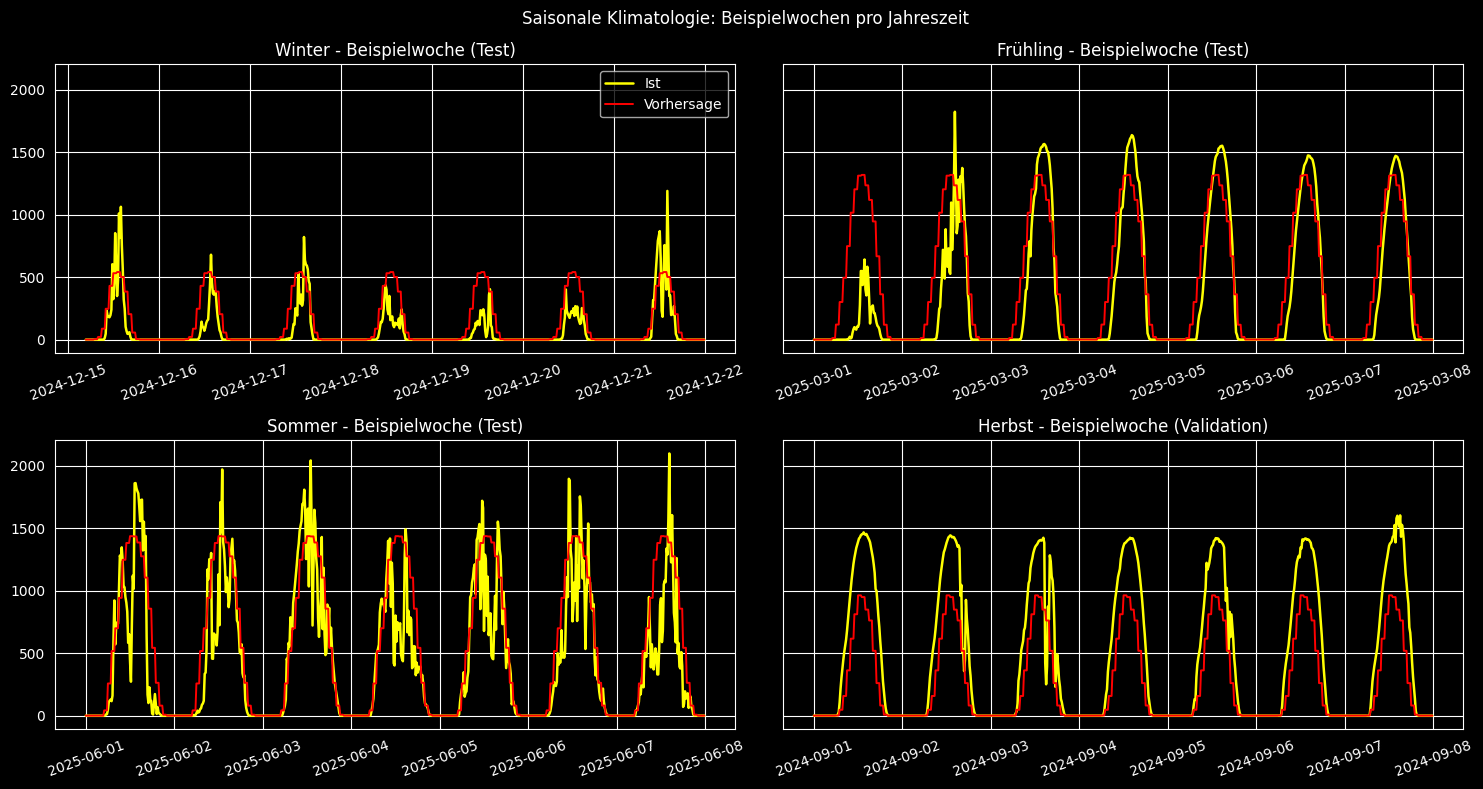

In [102]:
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
              6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}
SEASON_ORDER = ['Winter', 'Frühling', 'Sommer', 'Herbst']

def add_plot_cols(df_split, y_true_s, y_pred_s):
    out = df_split.copy()
    out['y_true'] = y_true_s.values
    out['y_pred'] = y_pred_s.values
    out['season'] = out['timestamp'].dt.month.map(SEASON_MAP)
    return out

test_plot = add_plot_cols(test, y_test, pred_test)
val_plot = add_plot_cols(val, y_val, pred_val)

def pick_example_week(df, season_name):
    sub = df[df['season'] == season_name].copy().sort_values('timestamp')
    if sub.empty:
        return None
    start = sub['timestamp'].min().floor('D')
    end = start + pd.Timedelta(days=7)
    week = sub[(sub['timestamp'] >= start) & (sub['timestamp'] < end)]
    return week if not week.empty else sub

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
for ax, season_name in zip(axes.flat, SEASON_ORDER):
    week = pick_example_week(test_plot, season_name)
    source_label = 'Test'
    if week is None:
        week = pick_example_week(val_plot, season_name)
        source_label = 'Validation'
    if week is None:
        ax.set_title(f'{season_name} (keine Daten)')
        ax.axis('off')
        continue

    ax.plot(week['timestamp'], week['y_true'], label='Ist', color='yellow', linewidth=1.8)
    ax.plot(week['timestamp'], week['y_pred'], label='Vorhersage', color='red', linewidth=1.4)
    ax.set_title(f'{season_name} - Beispielwoche ({source_label})')
    ax.tick_params(axis='x', rotation=20)

axes[0, 0].legend(loc='upper right')
fig.suptitle('Saisonale Klimatologie: Beispielwochen pro Jahreszeit')
plt.tight_layout()
plt.show()


,mae,rmse
split,,
Validation,184.49,433.26
Test,185.28,461.29


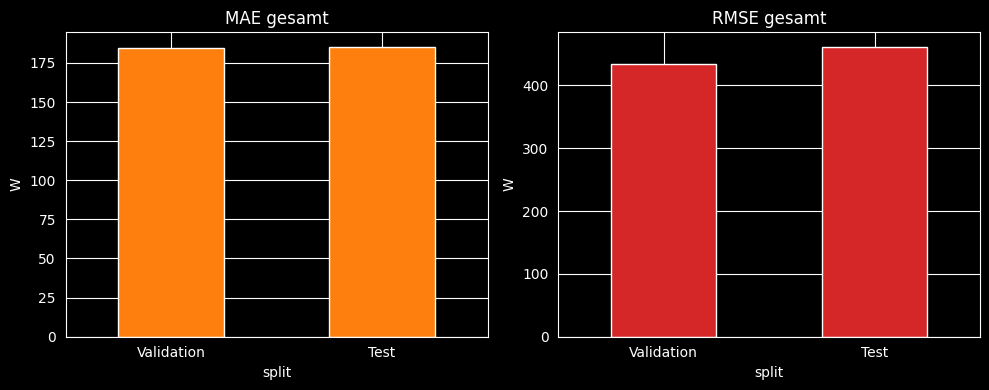

In [103]:
error_overall = pd.DataFrame({
    'split': ['Validation', 'Test'],
    'mae': [mae(y_val, pred_val), mae(y_test, pred_test)],
    'rmse': [rmse(y_val, pred_val), rmse(y_test, pred_test)],
}).set_index('split')

display(error_overall.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
error_overall['mae'].plot(kind='bar', ax=axes[0], color='tab:orange', rot=0)
axes[0].set_title('MAE gesamt')
axes[0].set_ylabel('W')

error_overall['rmse'].plot(kind='bar', ax=axes[1], color='tab:red', rot=0)
axes[1].set_title('RMSE gesamt')
axes[1].set_ylabel('W')

plt.tight_layout()
plt.show()


In [ ]:
def naive_predict(df, _features):
    preds = predict_climatological_mean_by_season(seasonal_means, df)
    return preds.set_axis(df.set_index("timestamp").index)

result = run_pipeline(
    model_name="climatology_seasonal",
    predict_fn=naive_predict,
    train=train,
    val=val,
    features=[],
    feature_set_key=None,
    results_dir=RESULTS_DIR,
)
print(pd.DataFrame(result["splits"]).T[["rmse", "mae", "nrmse", "skill_mae"]].round(4))

if RUN_TEST:
    evaluate_on_test(result, naive_predict, test, [], RESULTS_DIR)
